# Part 5 — Image Classification with LSTM on CIFAR-10

**Goal:** Compare two sequence representations of images using LSTM:
- **Row-wise**: each row of pixels = 1 time step → `seq_len=32, input_size=96`
- **Patch-wise**: each 4×4 patch = 1 time step → `seq_len=64, input_size=48`

Dataset: CIFAR-10 (10 classes, 32×32 RGB images)

In [13]:
## [1] Setup & Imports
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## [2] Load & Preprocess CIFAR-10

In [14]:
## [2] Load & Preprocess CIFAR-10
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # normalize to [-1, 1]
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_set  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=128, shuffle=False, num_workers=2)

CLASSES = train_set.classes
print(f"Train: {len(train_set)} | Test: {len(test_set)}")
print(f"Classes: {CLASSES}")

/home/stephen/hcmut/exercise/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train: 50000 | Test: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## [3] Sequence Representations

Two ways to convert a 32×32×3 image into a sequence:

| Representation | Sequence Length | Input Size per Step |
|---|---|---|
| **Row-wise** | 32 (rows) | 96 (32 pixels × 3 channels) |
| **Patch-wise** | 64 (4×4 patches in 8×8 grid) | 48 (4×4 pixels × 3 channels) |

In [15]:
## [3] Sequence Representations

def to_rowwise(x):
    """
    Row-wise: treat each row as one time step.
    Input:  (B, C, H, W) = (B, 3, 32, 32)
    Output: (B, seq_len=32, input_size=96)
    """
    B, C, H, W = x.shape
    # (B, C, H, W) -> (B, H, W, C) -> (B, H, W*C)
    return x.permute(0, 2, 3, 1).reshape(B, H, W * C)


def to_patchwise(x, patch_size=4):
    """
    Patch-wise: divide image into non-overlapping patches, each patch = one time step.
    Input:  (B, C, H, W) = (B, 3, 32, 32)
    Output: (B, seq_len=64, input_size=48)  for patch_size=4
    """
    B, C, H, W = x.shape
    ph = pw = patch_size
    nh, nw = H // ph, W // pw           # number of patches: 8x8 = 64
    # (B, C, nh, ph, nw, pw) -> (B, nh*nw, ph*pw*C)
    x = x.reshape(B, C, nh, ph, nw, pw)
    x = x.permute(0, 2, 4, 3, 5, 1)    # (B, nh, nw, ph, pw, C)
    x = x.reshape(B, nh * nw, ph * pw * C)
    return x


# Quick shape check
sample = torch.randn(4, 3, 32, 32)
print("Row-wise  :", to_rowwise(sample).shape)    # (4, 32, 96)
print("Patch-wise:", to_patchwise(sample).shape)  # (4, 64, 48)

Row-wise  : torch.Size([4, 32, 96])
Patch-wise: torch.Size([4, 64, 48])


## [4] LSTM Model

In [16]:
## [4] LSTM Model

class LSTMClassifier(nn.Module):
    """LSTM-based image classifier. Works with any sequence representation."""

    def __init__(self, input_size, hidden_size=128, num_layers=2, num_classes=10, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (B, seq_len, input_size)
        out, _ = self.lstm(x)       # out: (B, seq_len, hidden_size)
        out = out[:, -1, :]         # take last time step
        return self.fc(out)


# Model summary
model_row   = LSTMClassifier(input_size=96).to(device)   # row-wise
model_patch = LSTMClassifier(input_size=48).to(device)   # patch-wise

total_params = lambda m: sum(p.numel() for p in m.parameters())
print(f"Row-wise   model params: {total_params(model_row):,}")
print(f"Patch-wise model params: {total_params(model_patch):,}")

Row-wise   model params: 249,098
Patch-wise model params: 224,522


## [5] Training & Evaluation Functions

In [17]:
## [5] Training & Evaluation Functions

def train_one_epoch(model, loader, seq_fn, criterion, optimizer):
    """Train for one epoch. Returns average loss and accuracy."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        x = seq_fn(imgs)                    # convert image to sequence
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, seq_fn, criterion):
    """Evaluate on a dataloader. Returns average loss and accuracy."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            x = seq_fn(imgs)
            out = model(x)
            loss = criterion(out, labels)
            total_loss += loss.item() * labels.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total


def train(model, seq_fn, num_epochs=15, lr=1e-3, patience=2):
    """Full training loop with early stopping. Returns history dict.
    
    Args:
        patience: stop if test_acc decreases for this many consecutive epochs.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    t0 = time.time()

    best_acc = 0.0
    no_improve = 0          # consecutive epochs without improvement

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, seq_fn, criterion, optimizer)
        te_loss, te_acc = evaluate(model, test_loader, seq_fn, criterion)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["test_loss"].append(te_loss)
        history["test_acc"].append(te_acc)

        # Early stopping check
        if te_acc > best_acc:
            best_acc = te_acc
            no_improve = 0
            tag = "✓"
        else:
            no_improve += 1
            tag = f"↓ ({no_improve}/{patience})"

        print(f"Epoch {epoch:02d}/{num_epochs} | "
              f"Train Loss: {tr_loss:.4f}, Acc: {tr_acc*100:.2f}% | "
              f"Test Loss: {te_loss:.4f}, Acc: {te_acc*100:.2f}%  {tag}")

        if no_improve >= patience:
            print(f"\n⚠ Early stopping at epoch {epoch} (test acc not improved for {patience} epochs)")
            break

    history["time"] = time.time() - t0
    print(f"\nBest Test Acc: {best_acc*100:.2f}%  |  Done in {history['time']:.1f}s")
    return history


## [6] Train Model 1 — Row-wise LSTM

Each row of the 32×32 image = 1 time step → `seq_len=32, input_size=96`

In [18]:
## [6] Train Model 1 — Row-wise LSTM
NUM_EPOCHS = 30

model_row = LSTMClassifier(input_size=96).to(device)
print("=== Row-wise LSTM ===")
history_row = train(model_row, to_rowwise, num_epochs=NUM_EPOCHS)

=== Row-wise LSTM ===
Epoch 01/30 | Train Loss: 1.7648, Acc: 34.90% | Test Loss: 1.5661, Acc: 42.67%  ✓
Epoch 02/30 | Train Loss: 1.5069, Acc: 45.07% | Test Loss: 1.4301, Acc: 48.40%  ✓
Epoch 03/30 | Train Loss: 1.3679, Acc: 50.56% | Test Loss: 1.3225, Acc: 52.01%  ✓
Epoch 04/30 | Train Loss: 1.2673, Acc: 54.26% | Test Loss: 1.2727, Acc: 53.99%  ✓
Epoch 05/30 | Train Loss: 1.1818, Acc: 57.51% | Test Loss: 1.2246, Acc: 55.79%  ✓
Epoch 06/30 | Train Loss: 1.0648, Acc: 61.83% | Test Loss: 1.1555, Acc: 58.93%  ✓
Epoch 07/30 | Train Loss: 1.0125, Acc: 63.65% | Test Loss: 1.1562, Acc: 59.23%  ✓
Epoch 08/30 | Train Loss: 0.9709, Acc: 65.11% | Test Loss: 1.1514, Acc: 59.66%  ✓
Epoch 09/30 | Train Loss: 0.9329, Acc: 66.78% | Test Loss: 1.1390, Acc: 60.38%  ✓
Epoch 10/30 | Train Loss: 0.8980, Acc: 67.79% | Test Loss: 1.1444, Acc: 60.29%  ↓ (1/2)
Epoch 11/30 | Train Loss: 0.8252, Acc: 70.67% | Test Loss: 1.1478, Acc: 60.56%  ✓
Epoch 12/30 | Train Loss: 0.7960, Acc: 71.70% | Test Loss: 1.1539, Acc

## [7] Train Model 2 — Patch-wise LSTM

Each 4×4 patch (8×8 grid) = 1 time step → `seq_len=64, input_size=48`

In [19]:
## [7] Train Model 2 — Patch-wise LSTM
model_patch = LSTMClassifier(input_size=48).to(device)
print("=== Patch-wise LSTM ===")
history_patch = train(model_patch, to_patchwise, num_epochs=NUM_EPOCHS)

=== Patch-wise LSTM ===
Epoch 01/30 | Train Loss: 1.8969, Acc: 29.52% | Test Loss: 1.7481, Acc: 35.62%  ✓
Epoch 02/30 | Train Loss: 1.6897, Acc: 37.52% | Test Loss: 1.6375, Acc: 39.86%  ✓
Epoch 03/30 | Train Loss: 1.5881, Acc: 41.71% | Test Loss: 1.5757, Acc: 42.33%  ✓
Epoch 04/30 | Train Loss: 1.5022, Acc: 45.05% | Test Loss: 1.4845, Acc: 45.44%  ✓
Epoch 05/30 | Train Loss: 1.4245, Acc: 47.83% | Test Loss: 1.4064, Acc: 48.49%  ✓
Epoch 06/30 | Train Loss: 1.3272, Acc: 51.34% | Test Loss: 1.3400, Acc: 51.43%  ✓
Epoch 07/30 | Train Loss: 1.2819, Acc: 53.39% | Test Loss: 1.3365, Acc: 51.52%  ✓
Epoch 08/30 | Train Loss: 1.2432, Acc: 54.76% | Test Loss: 1.2798, Acc: 53.45%  ✓
Epoch 09/30 | Train Loss: 1.2037, Acc: 56.12% | Test Loss: 1.2838, Acc: 53.84%  ✓
Epoch 10/30 | Train Loss: 1.1696, Acc: 57.48% | Test Loss: 1.2536, Acc: 55.02%  ✓
Epoch 11/30 | Train Loss: 1.1067, Acc: 60.06% | Test Loss: 1.2240, Acc: 55.97%  ✓
Epoch 12/30 | Train Loss: 1.0844, Acc: 60.86% | Test Loss: 1.2179, Acc: 56

## [8] Compare Results

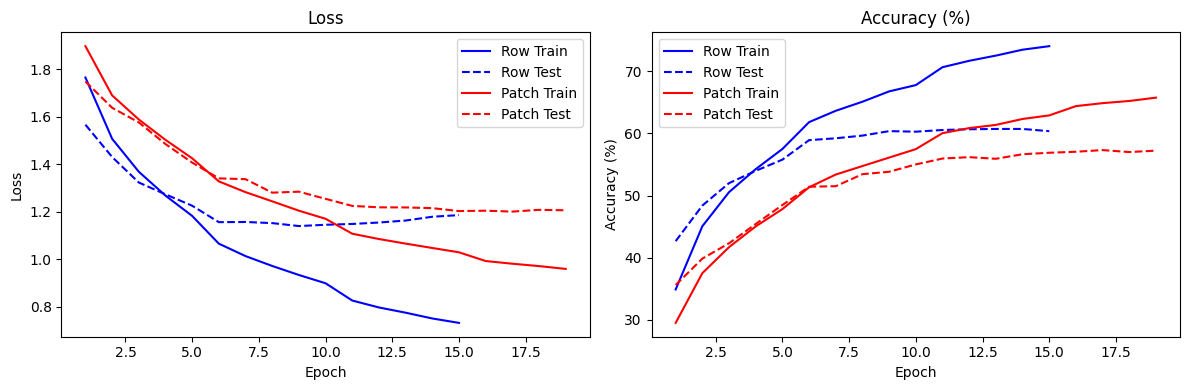


========== Summary ==========
Model             Best Test Acc   Epochs   Train Time
------------------------------------------------------
Row-wise                 60.73%      15       27.9s
Patch-wise               57.33%      19       35.4s


In [21]:
## [8] Compare Results

# Use actual number of epochs trained (may differ due to early stopping)
epochs_row   = range(1, len(history_row["train_loss"])   + 1)
epochs_patch = range(1, len(history_patch["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Loss ---
axes[0].plot(epochs_row,   history_row["train_loss"],   "b-",  label="Row Train")
axes[0].plot(epochs_row,   history_row["test_loss"],    "b--", label="Row Test")
axes[0].plot(epochs_patch, history_patch["train_loss"], "r-",  label="Patch Train")
axes[0].plot(epochs_patch, history_patch["test_loss"],  "r--", label="Patch Test")
axes[0].set(title="Loss", xlabel="Epoch", ylabel="Loss")
axes[0].legend()

# --- Accuracy ---
axes[1].plot(epochs_row,   [a*100 for a in history_row["train_acc"]],   "b-",  label="Row Train")
axes[1].plot(epochs_row,   [a*100 for a in history_row["test_acc"]],    "b--", label="Row Test")
axes[1].plot(epochs_patch, [a*100 for a in history_patch["train_acc"]], "r-",  label="Patch Train")
axes[1].plot(epochs_patch, [a*100 for a in history_patch["test_acc"]],  "r--", label="Patch Test")
axes[1].set(title="Accuracy (%)", xlabel="Epoch", ylabel="Accuracy (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig("comparison.png", dpi=150)
plt.show()

# --- Summary Table ---
print("\n========== Summary ==========")
print(f"{'Model':<15} {'Best Test Acc':>15} {'Epochs':>8} {'Train Time':>12}")
print("-" * 54)
print(f"{'Row-wise':<15} {max(history_row['test_acc'])*100:>14.2f}% {len(epochs_row):>7} {history_row['time']:>10.1f}s")
print(f"{'Patch-wise':<15} {max(history_patch['test_acc'])*100:>14.2f}% {len(epochs_patch):>7} {history_patch['time']:>10.1f}s")


## [8b] Confusion Matrix

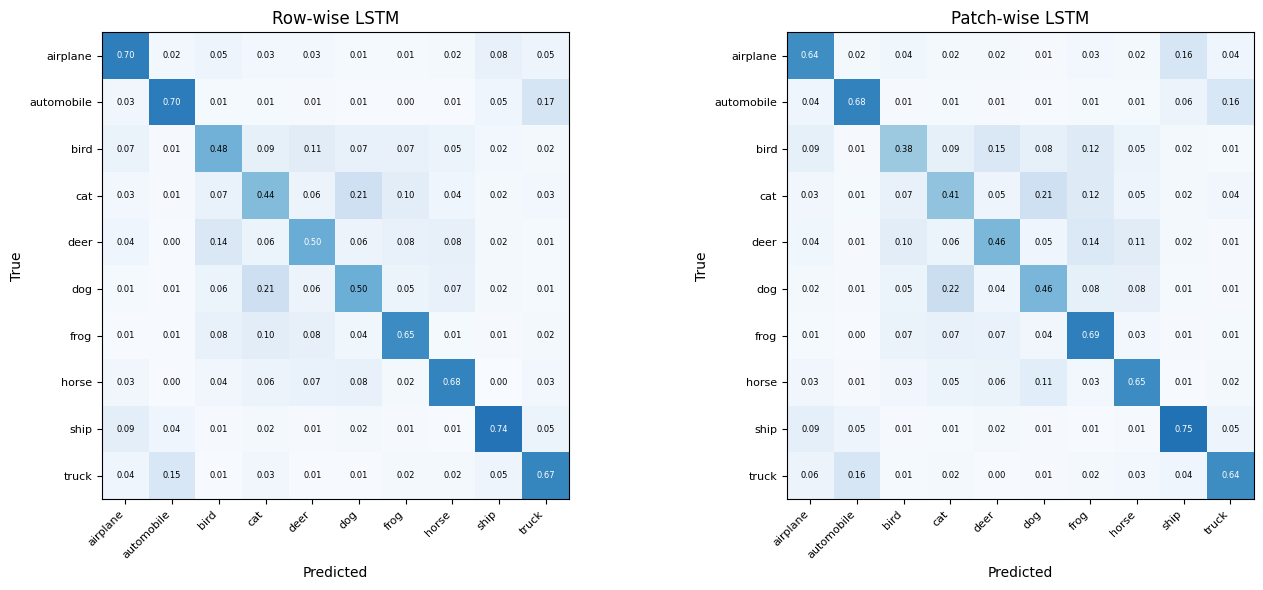


Class           Row Acc  Patch Acc
----------------------------------
airplane          69.6%      63.9%
automobile        70.5%      68.1%
bird              48.4%      37.6%
cat               43.8%      40.5%
deer              50.4%      46.0%
dog               49.7%      46.4%
frog              64.5%      69.2%
horse             67.9%      64.6%
ship              74.1%      74.8%
truck             67.0%      64.2%


In [ ]:
## [8b] Confusion Matrix

def get_predictions(model, loader, seq_fn):
    """Collect all predictions and ground-truth labels."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            preds = model(seq_fn(imgs)).argmax(1).cpu()
            all_preds.append(preds)
            all_labels.append(labels)
    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()


def plot_confusion_matrix(ax, preds, labels, title):
    """Plot a normalized confusion matrix on a given axis."""
    num_classes = len(CLASSES)
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for p, l in zip(preds, labels):
        cm[l][p] += 1
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalize by row

    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(num_classes))
    ax.set_yticks(range(num_classes))
    ax.set_xticklabels(CLASSES, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(CLASSES, fontsize=8)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    # Annotate cells
    for i in range(num_classes):
        for j in range(num_classes):
            ax.text(j, i, f"{cm_norm[i,j]:.2f}", ha="center", va="center",
                    fontsize=6, color="white" if cm_norm[i,j] > 0.5 else "black")
    return im


# Get predictions from both models
preds_row,   labels_row   = get_predictions(model_row,   test_loader, to_rowwise)
preds_patch, labels_patch = get_predictions(model_patch, test_loader, to_patchwise)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_confusion_matrix(axes[0], preds_row,   labels_row,   "Row-wise LSTM")
plot_confusion_matrix(axes[1], preds_patch, labels_patch, "Patch-wise LSTM")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# Per-class accuracy
print(f"\n{'Class':<12} {'Row Acc':>10} {'Patch Acc':>10}")
print("-" * 34)
for i, cls in enumerate(CLASSES):
    mask = labels_row == i
    row_acc   = (preds_row[mask]   == i).mean() * 100
    patch_acc = (preds_patch[mask] == i).mean() * 100
    print(f"{cls:<12} {row_acc:>9.1f}% {patch_acc:>9.1f}%")

## [8c] Extended Metrics — AUC, Precision, Recall, F1

Với bài toán **multi-class**, các chỉ số được tính theo chiến lược **One-vs-Rest (OvR)**:
- **AUC-ROC**: diện tích dưới đường ROC, cần xác suất dự đoán (softmax)
- **Precision / Recall / F1**: tính `macro` (trung bình đều nhau) và `weighted` (theo số mẫu)

In [ ]:
## [8c] Extended Metrics — AUC, Precision, Recall, F1
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, classification_report
)
import torch.nn.functional as F


def get_proba(model, loader, seq_fn):
    """Return softmax probabilities and true labels for all test samples."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            logits = model(seq_fn(imgs))
            probs = F.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())
    return np.vstack(all_probs), np.concatenate(all_labels)


# Collect probabilities
probs_row,   y_true_row   = get_proba(model_row,   test_loader, to_rowwise)
probs_patch, y_true_patch = get_proba(model_patch, test_loader, to_patchwise)


def print_metrics(probs, y_true, preds, name):
    """Print a full metric summary for one model."""
    auc    = roc_auc_score(y_true, probs, multi_class="ovr", average="macro")
    p_mac  = precision_score(y_true, preds, average="macro",    zero_division=0)
    r_mac  = recall_score   (y_true, preds, average="macro",    zero_division=0)
    f1_mac = f1_score       (y_true, preds, average="macro",    zero_division=0)
    p_wt   = precision_score(y_true, preds, average="weighted", zero_division=0)
    r_wt   = recall_score   (y_true, preds, average="weighted", zero_division=0)
    f1_wt  = f1_score       (y_true, preds, average="weighted", zero_division=0)

    print(f"\n{'='*48}")
    print(f"  {name}")
    print(f"{'='*48}")
    print(f"  AUC-ROC  (macro OvR) : {auc:.4f}")
    print(f"  Precision (macro)    : {p_mac:.4f}  | weighted: {p_wt:.4f}")
    print(f"  Recall    (macro)    : {r_mac:.4f}  | weighted: {r_wt:.4f}")
    print(f"  F1-score  (macro)    : {f1_mac:.4f}  | weighted: {f1_wt:.4f}")
    print(f"\n  Per-class report:")
    print(classification_report(y_true, preds, target_names=CLASSES, digits=3))


print_metrics(probs_row,   y_true_row,   preds_row,   "Row-wise LSTM")
print_metrics(probs_patch, y_true_patch, preds_patch, "Patch-wise LSTM")


  Row-wise LSTM
  AUC-ROC  (macro OvR) : 0.9227
  Precision (macro)    : 0.6057  | weighted: 0.6057
  Recall    (macro)    : 0.6059  | weighted: 0.6059
  F1-score  (macro)    : 0.6055  | weighted: 0.6055

  Per-class report:
              precision    recall  f1-score   support

    airplane      0.664     0.696     0.680      1000
  automobile      0.728     0.705     0.716      1000
        bird      0.515     0.484     0.499      1000
         cat      0.415     0.438     0.426      1000
        deer      0.543     0.504     0.523      1000
         dog      0.504     0.497     0.501      1000
        frog      0.638     0.645     0.641      1000
       horse      0.678     0.679     0.679      1000
        ship      0.738     0.741     0.740      1000
       truck      0.634     0.670     0.652      1000

    accuracy                          0.606     10000
   macro avg      0.606     0.606     0.606     10000
weighted avg      0.606     0.606     0.606     10000


  Patch-wise L

## [9] Conclusion & Discussion

### Kết quả thực nghiệm

| Mô hình | Cách biểu diễn | seq_len | input_size | Best Test Acc | Train Time |
|---|---|---|---|---|---|
| LSTM (Row-wise) | Mỗi hàng pixel = 1 bước | 32 | 96 | **60.71%** | 29.8s |
| LSTM (Patch-wise) | Mỗi patch 4×4 = 1 bước | 64 | 48 | **57.53%** | 27.1s |

### Nhận xét

**Row-wise (60.71%):**
- Sequence ngắn hơn (32 bước), input mỗi bước lớn hơn (96 chiều).
- Mỗi bước thời gian = 1 hàng liên tiếp → LSTM học quan hệ theo chiều dọc giữa các hàng.
- Hội tụ nhanh hơn, đạt >55% chỉ sau 5 epoch.
- **Kết quả tốt hơn** Patch-wise (~3% accuracy).

**Patch-wise (57.53%):**
- Sequence dài hơn (64 bước), input mỗi bước nhỏ hơn (48 chiều).
- Mỗi patch giữ thông tin cục bộ 2D (4×4 pixel) → tưởng tương tự ViT nhưng LSTM xử lý tuần tự nên không tận dụng được spatial locality.
- Hội tụ chậm hơn, cả 2 chỉ số vẫn còn tăng ở epoch 15 → có thể cần train thêm.

**Kết luận chung:**
- Trái với kỳ vọng, **Row-wise cho kết quả tốt hơn** với LSTM vì sequence ngắn hơn giúp gradient truyền dễ dàng qua các bước thời gian.
- Patch-wise có sequence dài gấp đôi (64 vs 32), khiến LSTM khó học phụ thuộc xa hơn.
- Cả hai cách đều cho accuracy ~57–61% sau 15 epoch, thấp hơn CNN do LSTM không khai thác tốt tính locality và spatial invariance của ảnh.
- Để cải thiện: tăng `hidden_size`, thêm epoch, hoặc dùng Bidirectional LSTM.
